In [1]:
import polars as pl
import numpy as np
import os
from tqdm.auto import tqdm  
from datetime import datetime, timedelta
from collections import defaultdict
from scipy.optimize import curve_fit
import polars.selectors as cs
from functools import reduce
from sklearn.metrics import mean_absolute_error
import itertools
import warnings
from scipy.optimize import OptimizeWarning
from functools import reduce


# Global varables
PARQUET_DIR = "mana_data/bar_data_parquet"
OUTPUT_DIR = "mana_data/propagator_model_data_cross_validation"
COLS = ["time","bid_price","ask_price","buy_vol","sell_vol","trade_volume", "unsided_vol", "trade_count"]

# Model parameters
WINDOW_DAYS = 21
DATE_FORMAT = "%Y%m%d"

In [2]:
def get_mid_prices(df, bid_price_col="bid_price", ask_price_col="ask_price"):
    """ 
    Get the mid price series from the dataframe. Drop bars 
    where either side of the quote is missing; forward-fill 
    the mid price.

    Args:
        df (pd.DataFrame): The dataframe containing the bid and ask prices.
        bid_price_col (str): The column name of the bid price.
        ask_price_col (str): The column name of the ask price.

    Returns:
        pd.Series: The mid price series.
    """
    mid_expr = ((pl.col(bid_price_col) + pl.col(ask_price_col)) / 2).forward_fill()
    return df.with_columns(mid_price=mid_expr)


def get_epsilons(
    df: pl.DataFrame,
    buy="buy_vol", sell="sell_vol", trade="trade_volume",
    epsilon_type="sqrt"  
) -> np.ndarray:
    """
    Returns ε_t based on the epsilon_type:
    - "sqrt": sign(q_t) * sqrt(|q_t| / V_t) (Bouchaud style)
    - "linear": q_t / V_t (Linear style)
    or 0 if V_t == 0.    

    Args:
        df (pl.DataFrame): The dataframe containing the buy, sell, trade, and unsided volumes.
        epsilon_type: Square root or linear.
        buy (str): The column name of the buy volume.
        sell (str): The column name of the sell volume.
        trade (str): The column name of the trade volume.

    Returns:
        pl.DataFrame: The dataframe with the epsilon series.
    
    """

    # signed volume and total signed volume
    signed  = (pl.col(buy) - pl.col(sell))
    total   = pl.col(trade)

    # Bouchaud style: square root of imbalance ratio
    if epsilon_type == "sqrt":
        eps_expr = (
            pl.when((total > 0) & (signed != 0))
            .then((signed.abs() / total).sqrt() * signed.sign())
            .otherwise(0.0)
            .fill_null(0.0)
            .alias("epsilon")
        )
    # Linear style: imbalance ratio
    elif epsilon_type == "linear":
        eps_expr = (
            pl.when((total > 0) & (signed != 0))
            .then(signed / total)
            .otherwise(0.0)
        )
    else:
        raise ValueError(f"Unknown epsilon_type: {epsilon_type}. Use 'sqrt' or 'linear'")

    return df.with_columns(epsilon=eps_expr)

def get_intraday_volatility(df_window, window_size=10):
    # assume df_window has column 'mid' already
    df = df_window.with_columns(
        pl.col("mid_price")
        .rolling_std(window_size=window_size, min_samples=window_size)
        .fill_null(strategy="backward")
        .fill_null(strategy="forward")
        .cast(pl.Float64)
        .alias("sigma")
    )
    return df

def get_returns(df_window):
    """
    Get the returns series from the dataframe.
    """
    df = df_window.with_columns([
    (pl.col("mid_price").log() - pl.col("mid_price").shift(1).log())
    .fill_null(0.0)
    .alias("returns")
    ])
    return df


def get_predictions_vectorized(df_day: pl.DataFrame, Y: float, tau: float, max_lag: int, epsilon_type: str = "sqrt") -> np.ndarray:
    """
    Generates predicted returns using a fast numpy convolution.
    Supports different epsilon types.

    Args:
        df_day (pl.DataFrame): The dataframe containing the epsilon series.
        Y (float): The Y parameter.
        tau (float): The tau parameter.
        max_lag (int): The maximum lag.
        epsilon_type (str): The epsilon type.

    Returns:
        np.ndarray: The predicted returns.

    """
    if "epsilon" not in df_day.columns:
        df_day = get_epsilons(df_day, epsilon_type=epsilon_type)
    
    epsilon_series = df_day['epsilon'].to_numpy()
    n_obs = len(epsilon_series)
    
    if n_obs < max_lag:
        return np.zeros(n_obs)
    
    # Construct the propagator G(k)
    lags = np.arange(1, max_lag + 1)
    G = Y * np.exp(-lags / tau)
    
    # Use np.convolve for fast computation
    valid_predictions = np.convolve(epsilon_series, G[::-1], mode='valid')
    valid_predictions = valid_predictions[:n_obs - max_lag]
    
    # Pad the start with zeros to match the original output shape
    padding = np.zeros(max_lag)
    
    return np.concatenate([padding, valid_predictions])


In [3]:

# Suppress the warning, as we are taking steps to mitigate it
warnings.simplefilter("ignore", OptimizeWarning)

# --- Define MAX_LAG settings to test ---
MAX_LAGS_TO_TEST = [5, 10, 20, 30]
EPSILON_TYPES = ["linear", "sqrt"]  # Add epsilon types to test

all_daily_params_dfs = []

# load daily 
symbols = os.listdir(PARQUET_DIR)

# try each epsilon type
for epsilon_type in tqdm(EPSILON_TYPES, desc="Testing Epsilon Types", position=0, leave=True):

    # Loop over each MAX_LAG setting for calibration
    for max_lag_val in tqdm(MAX_LAGS_TO_TEST, desc="Calibrating MAX_LAGs", position=0, leave=True):
        daily_params = defaultdict(dict)
    
        MAX_TAU = 180
        MIN_TAU = 0.5
        MIN_S = 1e-6

        for symbol in tqdm(symbols, desc="Processing symbols", position=1, leave=False):
            sym_in = os.path.join(PARQUET_DIR, symbol)
            sym_date_files = sorted(os.listdir(sym_in))
            sym_dates = [datetime.strptime(f.removeprefix("date="), DATE_FORMAT) for f in sym_date_files]
            sym_dates = sorted(sym_dates)

            for idx, current_date in enumerate(sym_dates):

                fn = f"date={current_date.strftime(DATE_FORMAT)}/data.parquet"
                path = os.path.join(sym_in, fn)

                try:
                    df_window = pl.read_parquet(path, columns=COLS)
                except FileNotFoundError:
                    continue

                if len(df_window) < max_lag_val + 1:
                    continue
                df_window = df_window.sort("time")

                # Feature engineering...
                df_window = get_mid_prices(df_window)
                df_window = get_returns(df_window)
                df_window = get_intraday_volatility(df_window)
                df_window = get_epsilons(df_window, epsilon_type=epsilon_type)  # Use specified epsilon type

                returns_i = df_window['returns'].to_numpy().astype(float)
                epsilon_i = df_window['epsilon'].to_numpy().astype(float)
            
                # Calibration logic...
                n = len(returns_i)
                S = np.array([np.dot(returns_i[k:], epsilon_i[:n-k]) / (n - k) for k in range(max_lag_val + 1)])
            
                E = S
                mask = E[1:] > MIN_S
                ys = np.log(E[1:][mask])
                ks = np.arange(max_lag_val + 1)[1:][mask]
                Es = E[1:][mask]
                Y_from_S0 = S[0] if not np.isnan(S[0]) else np.nan
                        
                tau, tau_pos, tau_weighted = np.nan, np.nan, np.nan
                def exp_model(k, S0, tau_fit): return S0 * np.exp(-k / tau_fit)
                
                if len(ks) >= 4:
                    weights = np.exp(-ks / 5)
                    try:
                        m_weighted, _ = np.polyfit(ks, ys, 1, w=weights)
                        m, _ = np.polyfit(ks, ys, 1)
                        tau_weighted = -1.0 / m_weighted
                        tau = -1.0 / m
                        
                        initial_tau_guess = abs(tau_weighted) if not np.isnan(tau_weighted) else max_lag_val
                        initial_tau_guess = max(MIN_TAU, min(initial_tau_guess, MAX_TAU))
                        
                        popt, _ = curve_fit(exp_model, ks, Es, p0=[Es[0], initial_tau_guess], 
                                          bounds=([0, MIN_TAU], [np.inf, MAX_TAU]), max_nfev=5000)
                        Y_from_S0 = popt[0]
                        tau_pos = popt[1]
                    except (np.linalg.LinAlgError, RuntimeError):
                        pass
                # Include epsilon_type in the output
                df_out = pl.DataFrame({
                    "tau": [float(tau)],
                    "tau_pos": [float(tau_pos)],
                    "tau_weighted": [float(tau_weighted)],
                    "Y": [float(Y_from_S0)],
                    "max_lag": [max_lag_val],
                    "epsilon_type": [epsilon_type],  # Add epsilon type
                    "symbol": [symbol],
                    "date": [current_date.strftime(DATE_FORMAT)]
                })

                daily_params.setdefault(symbol, {})[current_date.strftime(DATE_FORMAT)] = df_out
    
        # Consolidate results for the current max_lag_val and epsilon_type
        df_lag_all = pl.concat(
            [df for sym_data in daily_params.values() for df in sym_data.values()],
            rechunk=True
        )
        all_daily_params_dfs.append(df_lag_all)

# Combine all dataframes vertically
df_all = pl.concat(all_daily_params_dfs, how="vertical")

df_all = df_all.with_columns(
    pl.col("date").str.strptime(pl.Date, DATE_FORMAT)
).sort(["symbol", "date", "epsilon_type", "max_lag"])

print("\nDataFrame with both epsilon types and max_lag as columns:")
print(df_all.head())

Testing Epsilon Types:   0%|          | 0/2 [00:00<?, ?it/s]

Calibrating MAX_LAGs:   0%|          | 0/4 [00:00<?, ?it/s]

Processing symbols:   0%|          | 0/412 [00:00<?, ?it/s]

Processing symbols:   0%|          | 0/412 [00:00<?, ?it/s]

Processing symbols:   0%|          | 0/412 [00:00<?, ?it/s]

...

Processing symbols:   0%|          | 0/412 [00:00<?, ?it/s]

Processing symbols:   0%|          | 0/412 [00:00<?, ?it/s]

Processing symbols:   0%|          | 0/412 [00:00<?, ?it/s]

Processing symbols:   0%|          | 0/412 [00:00<?, ?it/s]


DataFrame with both epsilon types and max_lag as columns:
shape: (5, 8)
┌───────────┬────────────┬──────────────┬──────────┬─────────┬──────────────┬────────┬────────────┐
│ tau       ┆ tau_pos    ┆ tau_weighted ┆ Y        ┆ max_lag ┆ epsilon_type ┆ symbol ┆ date       │
│ ---       ┆ ---        ┆ ---          ┆ ---      ┆ ---     ┆ ---          ┆ ---    ┆ ---        │
│ f64       ┆ f64        ┆ f64          ┆ f64      ┆ i64     ┆ str          ┆ str    ┆ date       │
╞═══════════╪════════════╪══════════════╪══════════╪═════════╪══════════════╪════════╪════════════╡
│ NaN       ┆ NaN        ┆ NaN          ┆ 0.000339 ┆ 5       ┆ linear       ┆ sym=A  ┆ 2022-01-03 │
│ 19.817841 ┆ 21.578198  ┆ 12.39615     ┆ 0.000045 ┆ 10      ┆ linear       ┆ sym=A  ┆ 2022-01-03 │
│ 38.128414 ┆ 103.145916 ┆ 20.817842    ┆ 0.000041 ┆ 20      ┆ linear       ┆ sym=A  ┆ 2022-01-03 │
│ 26.840147 ┆ 41.915586  ┆ 20.606531    ┆ 0.000044 ┆ 30      ┆ linear       ┆ sym=A  ┆ 2022-01-03 │
│ NaN       ┆ NaN        ┆ 

In [4]:
# The input df_all is already in long format with a 'max_lag' column

# List of parameter columns to apply rolling medians to
param_cols_to_smooth = ["Y", "tau", "tau_pos", "tau_weighted"]

# --- Dynamically create rolling median expressions ---
rolling_exprs = []
window_sizes = [WINDOW_DAYS, int(WINDOW_DAYS * 1.5), int(WINDOW_DAYS * 2), int(WINDOW_DAYS * 3)]

for col_name in param_cols_to_smooth:
    # Use fill_nan(None) to convert NaNs to nulls for Polars
    base_col = pl.col(col_name).fill_nan(None)
    for window in window_sizes:
        rolling_exprs.append(
            base_col
            # The .over() clause is key: it calculates the rolling median within each symbol AND max_lag group
            .rolling_median(window_size=window, min_samples=1, center=True)
            .over(["symbol", "max_lag"])
            .alias(f"{col_name}_median_{window}")
        )

# --- Apply all expressions to the DataFrame ---
df_rolling = df_all.with_columns(rolling_exprs)

print("Long-format DataFrame with all rolling parameters generated:")
print(df_rolling.head())

Long-format DataFrame with all rolling parameters generated:
shape: (5, 24)
┌───────────┬───────────┬───────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ tau       ┆ tau_pos   ┆ tau_weigh ┆ Y        ┆ … ┆ tau_weigh ┆ tau_weigh ┆ tau_weigh ┆ tau_weigh │
│ ---       ┆ ---       ┆ ted       ┆ ---      ┆   ┆ ted_media ┆ ted_media ┆ ted_media ┆ ted_media │
│ f64       ┆ f64       ┆ ---       ┆ f64      ┆   ┆ n_21      ┆ n_31      ┆ n_42      ┆ n_63      │
│           ┆           ┆ f64       ┆          ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│           ┆           ┆           ┆          ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════════╪═══════════╪═══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ NaN       ┆ NaN       ┆ NaN       ┆ 0.000339 ┆ … ┆ -3.448365 ┆ -3.448365 ┆ -3.448365 ┆ -3.448365 │
│ 19.817841 ┆ 21.578198 ┆ 12.39615  ┆ 0.000045 ┆ … ┆ 7.874467  ┆ 4.836264  ┆ 3.620269  ┆ 3.353267  │
│ 38.128414 ┆ 1

/var/folders/mn/sstp0slh8xjckg0059bj70p80000gp/T/ipykernel_44037/534232165.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


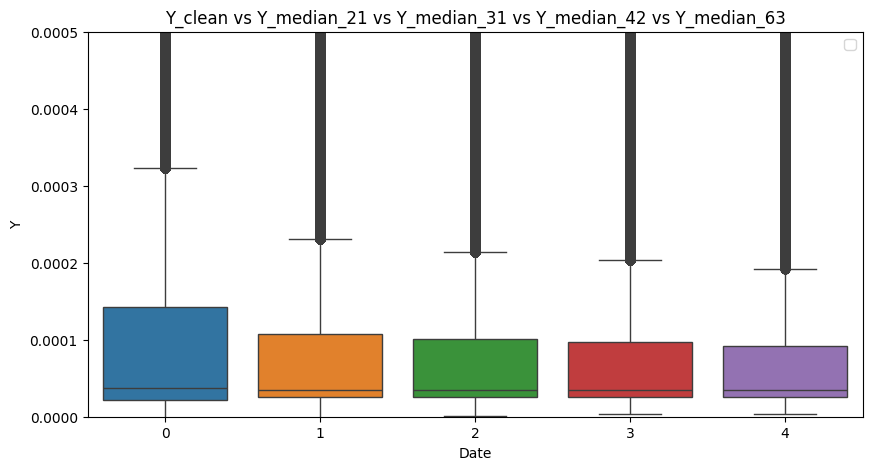

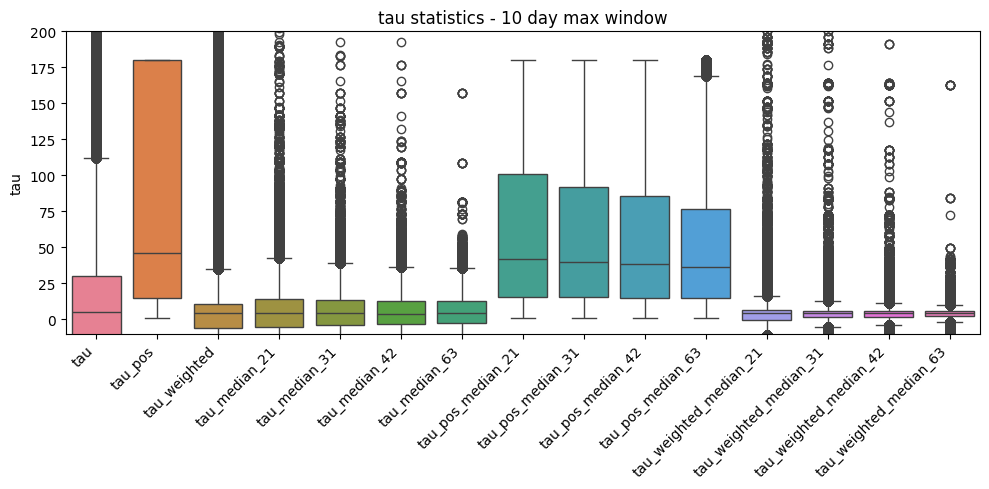

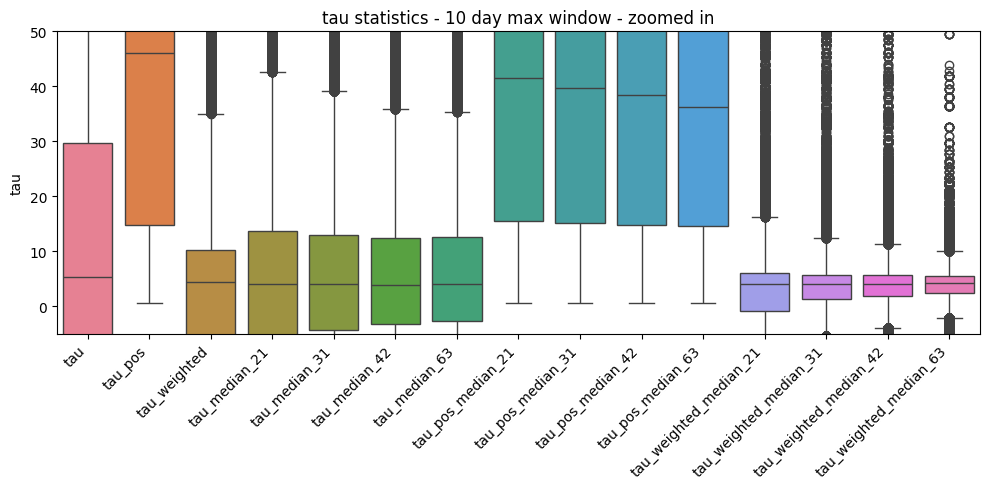

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# remove first WINDOW_DAYS days from the data to discard warm-up data which may be noisy
#df_rolling = df_rolling.filter(pl.col("date") > pl.col("date").min() + timedelta(days=WINDOW_DAYS))


# plot rangets of Y_clean, Y_ewm, tau_clean, tau_ewm
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_rolling[["Y", "Y_median_21", "Y_median_31", "Y_median_42", "Y_median_63"]])
plt.xlabel("Date")
plt.ylabel("Y")
plt.ylim(0, 0.0005)
plt.title("Y_clean vs Y_median_21 vs Y_median_31 vs Y_median_42 vs Y_median_63")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
# plot as box plots loop through all tau columns
titles = [col for col in df_rolling.columns if "tau" in col]
ax = sns.boxplot(data=df_rolling[titles])
positions = list(range(len(titles)))
ax.set_xticks(positions)

# Then set the rotated labels
ax.set_xticklabels(titles, rotation=45, ha='right')
plt.ylabel("tau")
plt.ylim(-10, 200)
plt.title("tau statistics - 10 day max window")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
# plot as box plots loop through all tau columns
titles = [col for col in df_rolling.columns if "tau" in col]
ax = sns.boxplot(data=df_rolling[titles])
positions = list(range(len(titles)))
ax.set_xticks(positions)

# Then set the rotated labels
ax.set_xticklabels(titles, rotation=45, ha='right')
plt.ylabel("tau")
plt.ylim(-5, 50)
plt.title("tau statistics - 10 day max window - zoomed in")
plt.tight_layout()
plt.show()

shape: (402, 15)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ symbol   ┆ tau_pos_p ┆ tau_weigh ┆ tau_media ┆ … ┆ tau_weigh ┆ tau_weigh ┆ tau_weigh ┆ tau_weigh │
│ ---      ┆ erc_neg   ┆ ted_perc_ ┆ n_21_perc ┆   ┆ ted_media ┆ ted_media ┆ ted_media ┆ ted_media │
│ str      ┆ ---       ┆ neg       ┆ _neg      ┆   ┆ n_21_perc ┆ n_31_perc ┆ n_42_perc ┆ n_63_perc │
│          ┆ f64       ┆ ---       ┆ ---       ┆   ┆ _ne…      ┆ _ne…      ┆ _ne…      ┆ _ne…      │
│          ┆           ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│          ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ sym=A    ┆ 0.0       ┆ 0.307773  ┆ 0.37961   ┆ … ┆ 0.287419  ┆ 0.208955  ┆ 0.175013  ┆ 0.137605  │
│ sym=AAL  ┆ 0.0       ┆ 0.295693  ┆ 0.471196  ┆ … ┆ 0.207065  ┆ 0.1424   

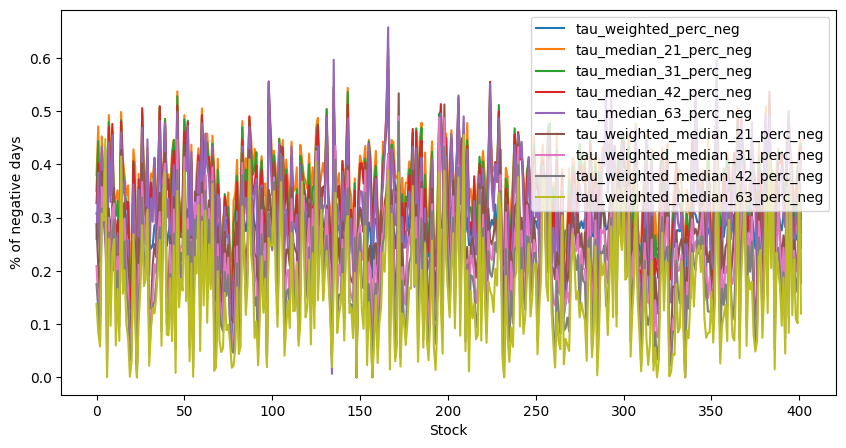

shape: (238, 15)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ date      ┆ tau_pos_p ┆ tau_weigh ┆ tau_media ┆ … ┆ tau_weigh ┆ tau_weigh ┆ tau_weigh ┆ tau_weig │
│ ---       ┆ erc_neg   ┆ ted_perc_ ┆ n_21_perc ┆   ┆ ted_media ┆ ted_media ┆ ted_media ┆ hted_med │
│ date      ┆ ---       ┆ neg       ┆ _neg      ┆   ┆ n_21_perc ┆ n_31_perc ┆ n_42_perc ┆ ian_63_p │
│           ┆ f64       ┆ ---       ┆ ---       ┆   ┆ _ne…      ┆ _ne…      ┆ _ne…      ┆ erc_ne…  │
│           ┆           ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2022-06-0 ┆ 0.0       ┆ 0.315104  ┆ 0.368825  ┆ … ┆ 0.263351  ┆ 0.240105  ┆ 0.1809    ┆ 0.157552 │
│ 1         ┆           ┆           ┆           ┆   ┆           ┆         

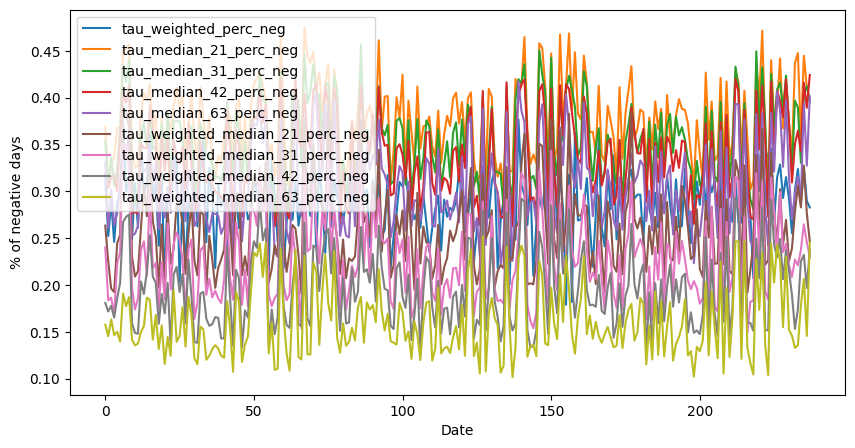

In [6]:

# calculate for each tau column by % of negative days by stock
perc_neg = (
    df_rolling
    .group_by("symbol")
    .agg([
        (pl.col(col).lt(0).mean()).alias(f"{col}_perc_neg")
        for col in df_rolling.select(cs.starts_with("tau_")).columns
    ])
)
perc_neg.sort(f"tau_median_63_perc_neg", descending=True)
print(perc_neg)

# plot the % of negative days for each tau column
plt.figure(figsize=(10, 5))
columns = [col for col in perc_neg.columns if "perc_neg" in col]
# remove _pos_ in column name
columns = [col for col in columns if "_pos_" not in col]
for col in columns:
  plt.plot(perc_neg[col], label=col)
plt.legend()
plt.xlabel("Stock")
plt.ylabel("% of negative days")
plt.show()


# plot the % of negative stocks by day
perc_neg_day = (
    df_rolling
    .group_by("date")
    .agg([
        (pl.col(col).lt(0).mean()).alias(f"{col}_perc_neg")
        for col in df_rolling.select(cs.starts_with("tau_")).columns
    ])
)

print(perc_neg_day)

# plot by day
plt.figure(figsize=(10, 5))
columns = [col for col in perc_neg_day.columns if "perc_neg" in col]
# remove _pos_ in column name
columns = [col for col in columns if "_pos_" not in col]
for col in columns:
  plt.plot(perc_neg_day[col], label=col)
plt.legend()
plt.xlabel("Date")
plt.ylabel("% of negative days")
plt.show()


In [7]:
# Stock-by-Stock Cross-Validation including epsilon type
# This follows after the rolling median calculations

# Configuration
TRAIN_WINDOW_DAYS = 63
TEST_WINDOW_DAYS = 21

# Identify all parameter columns and create the grid including epsilon types
y_param_cols = sorted([col for col in df_rolling.columns if col.startswith("Y_") and "median" in col])
tau_param_cols = sorted([col for col in df_rolling.columns if col.startswith("tau_") and "median" in col])
max_lag_values = df_rolling['max_lag'].unique().to_list()
epsilon_types = df_rolling['epsilon_type'].unique().to_list()

# Create parameter grid including epsilon type
param_grid = list(itertools.product(y_param_cols, tau_param_cols, max_lag_values, epsilon_types))
print(f"Created parameter grid with {len(param_grid)} combinations to test per stock.")

# Stock-by-Stock Cross-Validation
best_params_per_stock = []
all_fold_results = []
symbols = df_rolling['symbol'].unique().to_list()

for symbol in tqdm(symbols, desc="Finding Best Params per Symbol"):
    
    try:
        sym_in_dir = os.path.join(PARQUET_DIR, symbol)
        date_files = sorted(os.listdir(sym_in_dir))
        
        # Load relevant data for this stock
        df_sym_params_all = df_rolling.filter(pl.col("symbol") == symbol)
        min_date_needed = df_sym_params_all['date'].min()
        
        relevant_date_files = [f for f in date_files if datetime.strptime(f.removeprefix("date="), DATE_FORMAT).date() >= min_date_needed]
        
        daily_dfs = [pl.read_parquet(os.path.join(sym_in_dir, f, "data.parquet"))
                    .with_columns(date=pl.lit(datetime.strptime(f.removeprefix("date="), DATE_FORMAT).date())) 
                    for f in relevant_date_files]
        if not daily_dfs: continue
        df_sym_full = pl.concat(daily_dfs).sort("time")
        df_sym_full = df_sym_full.pipe(get_mid_prices).pipe(get_returns)
        
    except (FileNotFoundError, pl.exceptions.NoDataError):
        continue
    
    all_dates = sorted(df_sym_params_all['date'].unique().to_list())
    
    # Valid parameter sets must have positive Y and tau
    valid_param_grid = []
    for y_col, tau_col, max_lag, eps_type in param_grid:
        # Filter for this specific combination
        param_subset = df_sym_params_all.filter(
            (pl.col("max_lag") == max_lag) & (pl.col("epsilon_type") == eps_type)
        )
        
        if not param_subset.is_empty():
            is_y_valid = not param_subset[y_col].is_null().any() and (param_subset[y_col] > 0).all()
            is_tau_valid = not param_subset[tau_col].is_null().any() and (param_subset[tau_col] > 0).all()
            
            if is_y_valid and is_tau_valid:
                valid_param_grid.append((y_col, tau_col, max_lag, eps_type))
    
    if not valid_param_grid:
        print(f"Warning: No consistently positive parameter sets found for {symbol}. Skipping.")
        continue
    
    results_tracker = defaultdict(lambda: defaultdict(list))
    
    # Time window cross-validation
    for i in tqdm(range(len(all_dates) - (TRAIN_WINDOW_DAYS + TEST_WINDOW_DAYS) + 1),
                  desc=f"CV Folds for {symbol}", leave=False):
        
        train_start_date = all_dates[i]
        train_end_date = all_dates[i + TRAIN_WINDOW_DAYS - 1]
        test_start_date = all_dates[i + TRAIN_WINDOW_DAYS]
        test_end_date = all_dates[i + TRAIN_WINDOW_DAYS + TEST_WINDOW_DAYS - 1]
        
        df_train = df_sym_full.filter((pl.col("date") >= train_start_date) & (pl.col("date") <= train_end_date))
        df_test = df_sym_full.filter((pl.col("date") >= test_start_date) & (pl.col("date") <= test_end_date))
        
        if df_test.is_empty() or df_train.is_empty():
            continue
        
        # Re-compute epsilons for training data to get mean return
        mean_train_return = df_train['returns'].mean()
        
        for y_col, tau_col, max_lag, eps_type in valid_param_grid:
            
            params_row = df_sym_params_all.filter(
                (pl.col("date") == train_end_date) & 
                (pl.col("max_lag") == max_lag) &
                (pl.col("epsilon_type") == eps_type)
            )
            if params_row.is_empty(): continue
            
            Y_train, tau_train = params_row.get_column(y_col)[0], params_row.get_column(tau_col)[0]
            
            # Re-compute epsilons for test data with the specific epsilon type
            df_test_eps = get_epsilons(df_test, epsilon_type=eps_type)
            
            predictions = get_predictions_vectorized(df_test_eps, Y_train, tau_train, max_lag, epsilon_type=eps_type)
            eval_preds = predictions[max_lag:]
            eval_actuals = df_test_eps['returns'].to_numpy()[max_lag:]
            
            if len(eval_actuals) == 0: continue
            
            mae = mean_absolute_error(eval_actuals, eval_preds)
            ss_res = np.sum((eval_actuals - eval_preds)**2)
            ss_tot = np.sum((eval_actuals - mean_train_return)**2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            key = (y_col, tau_col, max_lag, eps_type)
            results_tracker[key]['r2'].append(r2)
            results_tracker[key]['mae'].append(mae)
            
            all_fold_results.append({
                "symbol": symbol, 
                "test_end_date": test_end_date,
                "y_param": y_col, 
                "tau_param": tau_col, 
                "max_lag": max_lag,
                "epsilon_type": eps_type,
                "r2": r2, 
                "mae": mae
            })
    
    if results_tracker:
        final_results = [
            {
                "Y_best_col": params[0],
                "tau_best_col": params[1],
                "max_lag_best": params[2],
                "epsilon_type_best": params[3],
                "mean_r2": np.mean(metrics['r2']),
                "mean_mae": np.mean(metrics['mae'])
            }
            for params, metrics in results_tracker.items()
        ]
        
        df_sym_results = pl.DataFrame(final_results)
        
        # Find the parameter set with the highest mean R²
        best_run = df_sym_results.sort("mean_r2", descending=True).row(0, named=True)
        
        best_params_per_stock.append({
            "symbol": symbol,
            **best_run
        })

# Final DataFrame with Best Parameters
df_best_params = pl.DataFrame(best_params_per_stock)

print("\n--- Best Parameter Sets Found per Stock (including epsilon type) ---")
print(df_best_params.sort("mean_r2", descending=True).head(20))

Created parameter grid with 384 combinations to test per stock.


Finding Best Params per Symbol:   0%|          | 0/402 [00:00<?, ?it/s]

CV Folds for sym=FMC:   0%|          | 0/155 [00:00<?, ?it/s]

CV Folds for sym=PEP:   0%|          | 0/155 [00:00<?, ?it/s]

CV Folds for sym=SRE:   0%|          | 0/155 [00:00<?, ?it/s]

...

CV Folds for sym=WBD:   0%|          | 0/87 [00:00<?, ?it/s]

CV Folds for sym=FAST:   0%|          | 0/155 [00:00<?, ?it/s]

CV Folds for sym=MMM:   0%|          | 0/155 [00:00<?, ?it/s]

CV Folds for sym=XLNX: 0it [00:00, ?it/s]


--- Best Parameter Sets Found per Stock (including epsilon type) ---
shape: (20, 7)
┌───────────┬─────────────┬─────────────────┬──────────────┬─────────────────┬──────────┬──────────┐
│ symbol    ┆ Y_best_col  ┆ tau_best_col    ┆ max_lag_best ┆ epsilon_type_be ┆ mean_r2  ┆ mean_mae │
│ ---       ┆ ---         ┆ ---             ┆ ---          ┆ st              ┆ ---      ┆ ---      │
│ str       ┆ str         ┆ str             ┆ i64          ┆ ---             ┆ f64      ┆ f64      │
│           ┆             ┆                 ┆              ┆ str             ┆          ┆          │
╞═══════════╪═════════════╪═════════════════╪══════════════╪═════════════════╪══════════╪══════════╡
│ sym=GOOGL ┆ Y_median_21 ┆ tau_pos_median_ ┆ 5            ┆ sqrt            ┆ 0.33616  ┆ 0.038278 │
│           ┆             ┆ 31              ┆              ┆                 ┆          ┆          │
│ sym=GOOG  ┆ Y_median_21 ┆ tau_pos_median_ ┆ 5            ┆ sqrt            ┆ 0.334524 ┆ 0.038297 │
│     

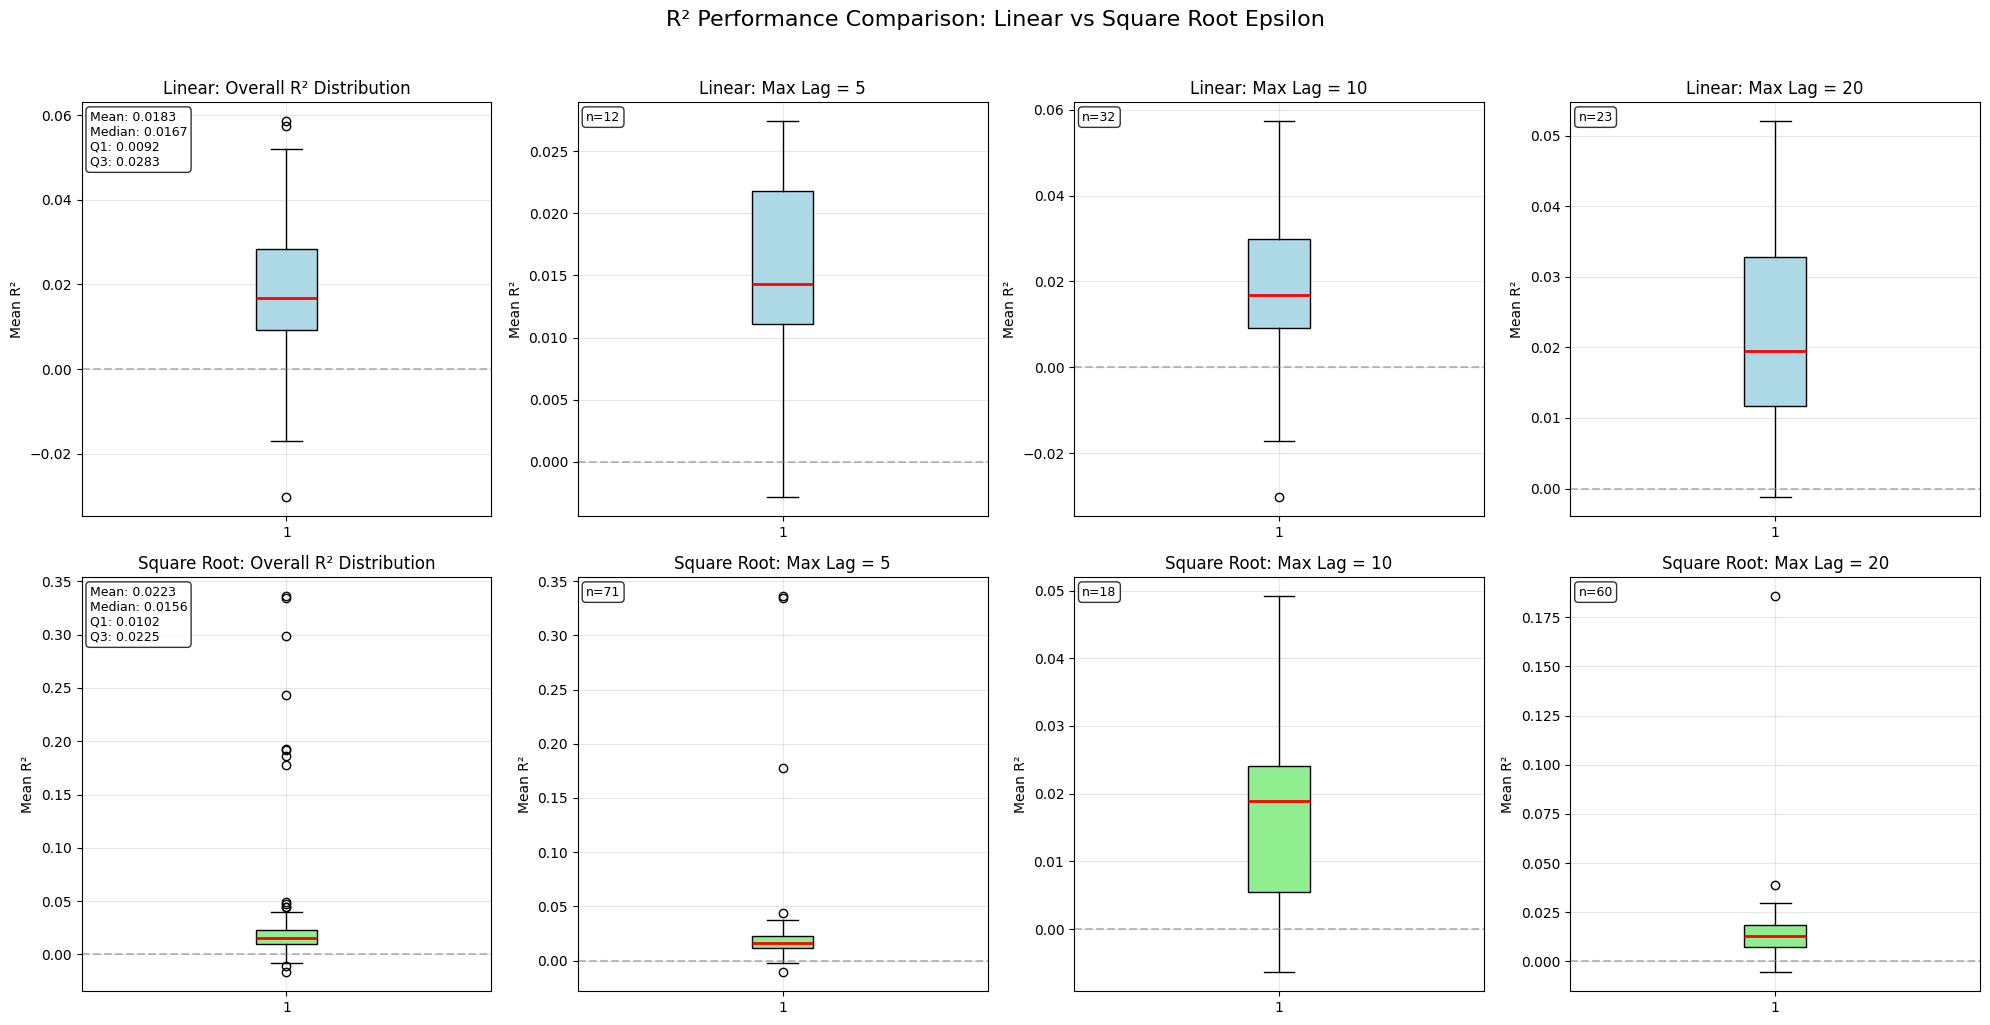

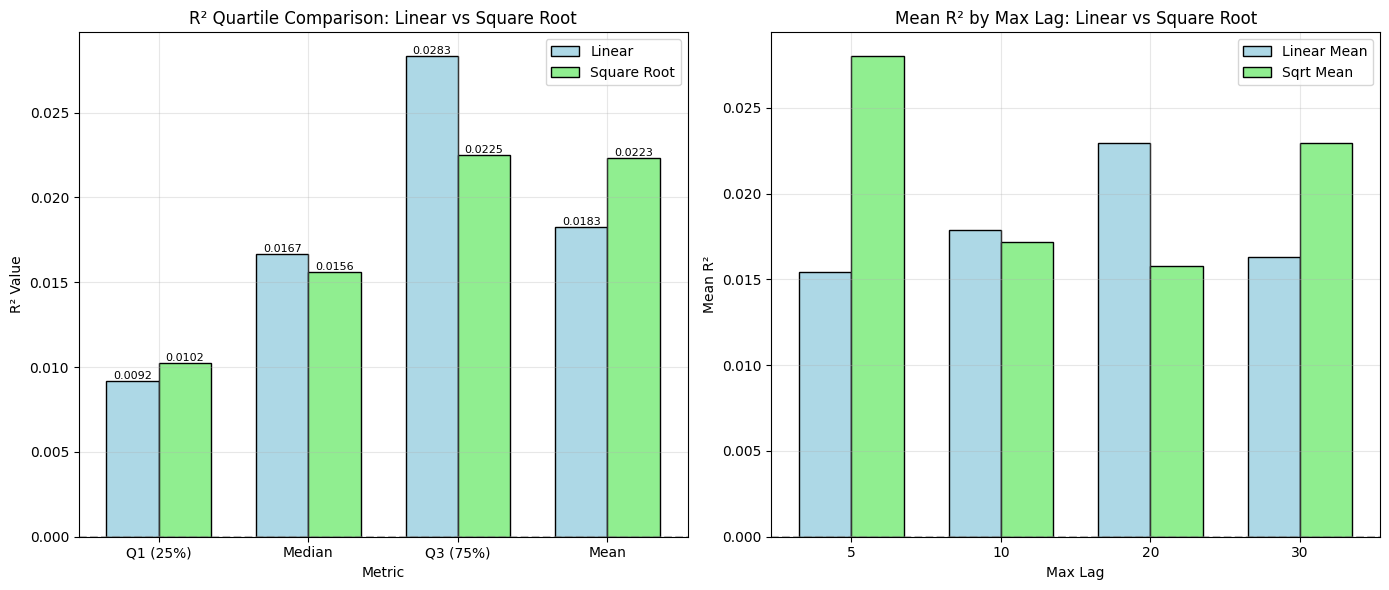


SUMMARY STATISTICS: LINEAR VS SQUARE ROOT EPSILON

Linear Epsilon:
------------------------------
Min       : -0.03031
Q1        :  0.00917
Median    :  0.01669
Q3        :  0.02832
Max       :  0.05857
Mean      :  0.01825

Square Root Epsilon:
------------------------------
Min       : -0.01694
Q1        :  0.01023
Median    :  0.01563
Q3        :  0.02248
Max       :  0.33616
Mean      :  0.02233

Comparison:
------------------------------
Mean R² Difference (Sqrt - Linear):  0.00408
Median R² Difference (Sqrt - Linear): -0.00106

Best Epsilon Type Selection:
Linear chosen as best: 99/388 (25.5%)
Square Root chosen as best: 289/388 (74.5%)

PERFORMANCE BY MAX LAG PREFERENCE

Max Lag = 5:
  Linear: 12 stocks, Mean R² = 0.01541
  Sqrt:   71 stocks, Mean R² = 0.02800

Max Lag = 10:
  Linear: 32 stocks, Mean R² = 0.01790
  Sqrt:   18 stocks, Mean R² = 0.01716

Max Lag = 20:
  Linear: 23 stocks, Mean R² = 0.02295
  Sqrt:   60 stocks, Mean R² = 0.01579

Max Lag = 30:
  Linear: 32 stocks,

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create comparison visualizations for linear vs sqrt epsilon types

# Separate results by epsilon type
df_linear = df_best_params.filter(pl.col("epsilon_type_best") == "linear")
df_sqrt = df_best_params.filter(pl.col("epsilon_type_best") == "sqrt")

# Function to compute quartiles
def compute_quartiles(df, metric="mean_r2"):
    values = df[metric].to_numpy()
    return {
        'min': np.min(values),
        'q1': np.percentile(values, 25),
        'median': np.percentile(values, 50),
        'q3': np.percentile(values, 75),
        'max': np.max(values),
        'mean': np.mean(values)
    }

# --- Main Comparison Plot: R² Quartiles Side by Side ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('R² Performance Comparison: Linear vs Square Root Epsilon', fontsize=16, y=1.02)

# Get unique max_lag values for consistent plotting
max_lags = sorted(df_best_params['max_lag_best'].unique().to_list())

for row_idx, (eps_type, df_eps) in enumerate([("Linear", df_linear), ("Square Root", df_sqrt)]):
    
    # Plot 1: Overall R² distribution
    ax = axes[row_idx, 0]
    data = df_eps['mean_r2'].to_numpy()
    
    # Create box plot
    bp = ax.boxplot([data], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue' if eps_type == "Linear" else 'lightgreen'),
                     medianprops=dict(color='red', linewidth=2))
    
    ax.set_title(f'{eps_type}: Overall R² Distribution')
    ax.set_ylabel('Mean R²')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    # Add statistics text
    stats = compute_quartiles(df_eps)
    stats_text = f"Mean: {stats['mean']:.4f}\nMedian: {stats['median']:.4f}\nQ1: {stats['q1']:.4f}\nQ3: {stats['q3']:.4f}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Plot 2-4: R² by max_lag
    for lag_idx, max_lag in enumerate(max_lags[:3]):  # Show first 3 max_lag values
        ax = axes[row_idx, lag_idx + 1]
        df_lag = df_eps.filter(pl.col("max_lag_best") == max_lag)
        
        if not df_lag.is_empty():
            data = df_lag['mean_r2'].to_numpy()
            bp = ax.boxplot([data], vert=True, patch_artist=True,
                           boxprops=dict(facecolor='lightblue' if eps_type == "Linear" else 'lightgreen'),
                           medianprops=dict(color='red', linewidth=2))
            
            ax.set_title(f'{eps_type}: Max Lag = {max_lag}')
            ax.set_ylabel('Mean R²')
            ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
            ax.grid(True, alpha=0.3)
            
            # Add count
            ax.text(0.02, 0.98, f"n={len(data)}", transform=ax.transAxes, fontsize=9,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# --- Detailed Comparison Plot: Quartile Ranges ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: R² Quartile comparison
ax = axes[0]
metrics_linear = compute_quartiles(df_linear, "mean_r2")
metrics_sqrt = compute_quartiles(df_sqrt, "mean_r2")

x_pos = np.array([0, 1])
width = 0.35

# Create grouped bar chart for quartiles
quartile_labels = ['Q1 (25%)', 'Median', 'Q3 (75%)', 'Mean']
linear_values = [metrics_linear['q1'], metrics_linear['median'], metrics_linear['q3'], metrics_linear['mean']]
sqrt_values = [metrics_sqrt['q1'], metrics_sqrt['median'], metrics_sqrt['q3'], metrics_sqrt['mean']]

x = np.arange(len(quartile_labels))
bars1 = ax.bar(x - width/2, linear_values, width, label='Linear', color='lightblue', edgecolor='black')
bars2 = ax.bar(x + width/2, sqrt_values, width, label='Square Root', color='lightgreen', edgecolor='black')

ax.set_xlabel('Metric')
ax.set_ylabel('R² Value')
ax.set_title('R² Quartile Comparison: Linear vs Square Root')
ax.set_xticks(x)
ax.set_xticklabels(quartile_labels)
ax.legend()
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Distribution by max_lag
ax = axes[1]
max_lag_comparison = []

for max_lag in max_lags:
    linear_lag = df_linear.filter(pl.col("max_lag_best") == max_lag)
    sqrt_lag = df_sqrt.filter(pl.col("max_lag_best") == max_lag)
    
    if not linear_lag.is_empty() and not sqrt_lag.is_empty():
        max_lag_comparison.append({
            'max_lag': max_lag,
            'linear_mean': linear_lag['mean_r2'].mean(),
            'sqrt_mean': sqrt_lag['mean_r2'].mean(),
            'linear_median': linear_lag['mean_r2'].median(),
            'sqrt_median': sqrt_lag['mean_r2'].median()
        })

if max_lag_comparison:
    df_comparison = pl.DataFrame(max_lag_comparison)
    
    x = np.arange(len(max_lag_comparison))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, [d['linear_mean'] for d in max_lag_comparison], 
                   width, label='Linear Mean', color='lightblue', edgecolor='black')
    bars2 = ax.bar(x + width/2, [d['sqrt_mean'] for d in max_lag_comparison], 
                   width, label='Sqrt Mean', color='lightgreen', edgecolor='black')
    
    ax.set_xlabel('Max Lag')
    ax.set_ylabel('Mean R²')
    ax.set_title('Mean R² by Max Lag: Linear vs Square Root')
    ax.set_xticks(x)
    ax.set_xticklabels([d['max_lag'] for d in max_lag_comparison])
    ax.legend()
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary Statistics Table ---
print("\n" + "="*70)
print("SUMMARY STATISTICS: LINEAR VS SQUARE ROOT EPSILON")
print("="*70)

print("\nLinear Epsilon:")
print("-" * 30)
linear_stats = compute_quartiles(df_linear, "mean_r2")
for key, value in linear_stats.items():
    print(f"{key.capitalize():10s}: {value:8.5f}")

print("\nSquare Root Epsilon:")
print("-" * 30)
sqrt_stats = compute_quartiles(df_sqrt, "mean_r2")
for key, value in sqrt_stats.items():
    print(f"{key.capitalize():10s}: {value:8.5f}")

print("\nComparison:")
print("-" * 30)
print(f"Mean R² Difference (Sqrt - Linear): {sqrt_stats['mean'] - linear_stats['mean']:8.5f}")
print(f"Median R² Difference (Sqrt - Linear): {sqrt_stats['median'] - linear_stats['median']:8.5f}")

# Count which epsilon type was chosen as best for each stock
n_linear_best = len(df_linear)
n_sqrt_best = len(df_sqrt)
total_stocks = n_linear_best + n_sqrt_best

print(f"\nBest Epsilon Type Selection:")
print(f"Linear chosen as best: {n_linear_best}/{total_stocks} ({100*n_linear_best/total_stocks:.1f}%)")
print(f"Square Root chosen as best: {n_sqrt_best}/{total_stocks} ({100*n_sqrt_best/total_stocks:.1f}%)")

# Performance by max_lag preference
print("\n" + "="*70)
print("PERFORMANCE BY MAX LAG PREFERENCE")
print("="*70)

for max_lag in max_lags:
    print(f"\nMax Lag = {max_lag}:")
    linear_lag = df_linear.filter(pl.col("max_lag_best") == max_lag)
    sqrt_lag = df_sqrt.filter(pl.col("max_lag_best") == max_lag)
    
    print(f"  Linear: {len(linear_lag)} stocks, Mean R² = {linear_lag['mean_r2'].mean() if not linear_lag.is_empty() else 0:.5f}")
    print(f"  Sqrt:   {len(sqrt_lag)} stocks, Mean R² = {sqrt_lag['mean_r2'].mean() if not sqrt_lag.is_empty() else 0:.5f}")

In [9]:
# --- Create the Final, Clean DataFrame for RL Loader and Plotting ---

print("\n--- Best Parameter Set Found per Stock ---")
print(df_best_params.sort("mean_r2", descending=True).head(50))

print("\n--- Worst Parameter Set Found per Stock ---")
print(df_best_params.sort("mean_r2", descending=False).head(50))

# This will hold the final results for all stocks
final_results_list = []

for row in tqdm(df_best_params.iter_rows(named=True), desc="Building Final Dataset", total=len(df_best_params)):
    # Get the best column names and lag for this specific stock
    symbol = row['symbol']
    y_col = row['Y_best_col']
    epsilon_type = row['epsilon_type_best']
    tau_col = row['tau_best_col']
    max_lag = row['max_lag_best']
    
    # Filter the rolling data to get the daily values for this stock's best parameters
    df_stock_best_daily = df_rolling.filter(
        (pl.col("symbol") == symbol) & (pl.col("max_lag") == max_lag)
    ).select(
        "symbol",
        "date",
        pl.col(y_col).alias("Y_best"),          # Rename to the final, clean name
        pl.col(tau_col).alias("tau_best"),      # Rename to the final, clean name
        pl.col("epsilon_type").alias("epsilon_type_best"),  # Use column name, not variable
        pl.lit(row['mean_r2']).alias("mean_r2_best"),  # Get mean_r2 from the current row
        pl.lit(max_lag).alias("max_lag_best")   # Add the best lag as a constant column
    )
    
    final_results_list.append(df_stock_best_daily)

# Concatenate all the results into a single, clean DataFrame
# The positivity filter is no longer needed here because we fixed it in the CV loop
df_final_for_rl = pl.concat(final_results_list).drop_nulls()

print("\n--- Final, Clean DataFrame Ready for RL Loader and Plotting ---")
print(df_final_for_rl.head())


--- Best Parameter Set Found per Stock ---
shape: (50, 7)
┌───────────┬─────────────┬─────────────────┬──────────────┬─────────────────┬──────────┬──────────┐
│ symbol    ┆ Y_best_col  ┆ tau_best_col    ┆ max_lag_best ┆ epsilon_type_be ┆ mean_r2  ┆ mean_mae │
│ ---       ┆ ---         ┆ ---             ┆ ---          ┆ st              ┆ ---      ┆ ---      │
│ str       ┆ str         ┆ str             ┆ i64          ┆ ---             ┆ f64      ┆ f64      │
│           ┆             ┆                 ┆              ┆ str             ┆          ┆          │
╞═══════════╪═════════════╪═════════════════╪══════════════╪═════════════════╪══════════╪══════════╡
│ sym=GOOGL ┆ Y_median_21 ┆ tau_pos_median_ ┆ 5            ┆ sqrt            ┆ 0.33616  ┆ 0.038278 │
│           ┆             ┆ 31              ┆              ┆                 ┆          ┆          │
│ sym=GOOG  ┆ Y_median_21 ┆ tau_pos_median_ ┆ 5            ┆ sqrt            ┆ 0.334524 ┆ 0.038297 │
│           ┆             ┆ 63  

Building Final Dataset:   0%|          | 0/388 [00:00<?, ?it/s]


--- Final, Clean DataFrame Ready for RL Loader and Plotting ---
shape: (5, 7)
┌─────────┬────────────┬──────────┬──────────┬───────────────────┬──────────────┬──────────────┐
│ symbol  ┆ date       ┆ Y_best   ┆ tau_best ┆ epsilon_type_best ┆ mean_r2_best ┆ max_lag_best │
│ ---     ┆ ---        ┆ ---      ┆ ---      ┆ ---               ┆ ---          ┆ ---          │
│ str     ┆ date       ┆ f64      ┆ f64      ┆ str               ┆ f64          ┆ i32          │
╞═════════╪════════════╪══════════╪══════════╪═══════════════════╪══════════════╪══════════════╡
│ sym=FMC ┆ 2022-01-03 ┆ 0.000035 ┆ 5.9197   ┆ linear            ┆ 0.029062     ┆ 20           │
│ sym=FMC ┆ 2022-01-03 ┆ 0.000035 ┆ 5.966627 ┆ sqrt              ┆ 0.029062     ┆ 20           │
│ sym=FMC ┆ 2022-01-04 ┆ 0.000037 ┆ 6.069143 ┆ linear            ┆ 0.029062     ┆ 20           │
│ sym=FMC ┆ 2022-01-04 ┆ 0.000039 ┆ 6.171659 ┆ sqrt              ┆ 0.029062     ┆ 20           │
│ sym=FMC ┆ 2022-01-05 ┆ 0.000039 ┆ 6.924698 ┆ l

In [10]:
print(df_final_for_rl.filter(pl.col("epsilon_type_best")=="sqrt").height)
print("Rows with mean_r2_best > 0.02:", df_final_for_rl.filter(pl.col("mean_r2_best") > 0.03).filter(pl.col("epsilon_type_best")=="sqrt").height)
print(df_final_for_rl.filter(pl.col("epsilon_type_best")=="linear").height)
print("Rows with mean_r2_best > 0.02:", df_final_for_rl.filter(pl.col("epsilon_type_best")=="linear").filter(pl.col("mean_r2_best") > 0.03).height)

90972
Rows with mean_r2_best > 0.02: 11520
90970
Rows with mean_r2_best > 0.02: 11520


In [16]:
print(df_final_for_rl.head())

shape: (5, 7)
┌─────────┬────────────┬──────────┬──────────┬───────────────────┬──────────────┬──────────────┐
│ symbol  ┆ date       ┆ Y_best   ┆ tau_best ┆ epsilon_type_best ┆ mean_r2_best ┆ max_lag_best │
│ ---     ┆ ---        ┆ ---      ┆ ---      ┆ ---               ┆ ---          ┆ ---          │
│ str     ┆ date       ┆ f64      ┆ f64      ┆ str               ┆ f64          ┆ i32          │
╞═════════╪════════════╪══════════╪══════════╪═══════════════════╪══════════════╪══════════════╡
│ sym=FMC ┆ 2022-01-03 ┆ 0.000035 ┆ 5.9197   ┆ linear            ┆ 0.029062     ┆ 20           │
│ sym=FMC ┆ 2022-01-03 ┆ 0.000035 ┆ 5.966627 ┆ sqrt              ┆ 0.029062     ┆ 20           │
│ sym=FMC ┆ 2022-01-04 ┆ 0.000037 ┆ 6.069143 ┆ linear            ┆ 0.029062     ┆ 20           │
│ sym=FMC ┆ 2022-01-04 ┆ 0.000039 ┆ 6.171659 ┆ sqrt              ┆ 0.029062     ┆ 20           │
│ sym=FMC ┆ 2022-01-05 ┆ 0.000039 ┆ 6.924698 ┆ linear            ┆ 0.029062     ┆ 20           │
└─────────┴─────

In [12]:
# --- Save the Optimized Parameters for the RL Loader ---

# Define the root directory where the data will be saved
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Saving daily parameters to: {OUTPUT_DIR}")

# Group the final DataFrame by symbol and date to write individual files
for (symbol, single_date), df_group in tqdm(df_final_for_rl.group_by(["symbol", "date"]), desc="Saving Files"):
    
    # Format the date and create the directory structure
    date_str = single_date.strftime('%Y%m%d')
    symbol_dir = os.path.join(OUTPUT_DIR, f"{symbol}")
    final_dir = os.path.join(symbol_dir, f"date={date_str}")
    os.makedirs(final_dir, exist_ok=True)
    
    # Define the final file path
    file_path = os.path.join(final_dir, "daily_params.parquet")
    
    # Write the single-row DataFrame for that day to a parquet file
    # We rename the columns to match what your loader expects, if needed, or save as is.
    # Assuming your loader will be updated to look for 'Y_best' and 'tau_best'.
    df_group.write_parquet(file_path)

print("\n--- Data saving complete. ---")
print(f"Your RL environment can now use the PropagatorParamLoader with the directory '{OUTPUT_DIR}'.")

Saving daily parameters to: mana_data/propagator_model_data_cross_validation


Saving Files: 0it [00:00, ?it/s]


--- Data saving complete. ---
Your RL environment can now use the PropagatorParamLoader with the directory 'mana_data/propagator_model_data_cross_validation'.


In [18]:
# DELETE?

import gc

# more memory efficient analysis

lf_all = pl.DataFrame(all_fold_results).lazy().with_columns(
    pl.col("r2").cast(pl.Float32),
    pl.col("mae").cast(pl.Float32),
)

# Keep only what's needed from best params; ensure one row per symbol
lf_best = df_best_params.lazy().select(
    "symbol", "Y_best_col", "tau_best_col", "max_lag_best",
).unique(subset=["symbol"])

# Rename to align keys, then join on all keys (no post-filter)
lf_best_keys = lf_best.rename({
    "Y_best_col": "y_param",
    "tau_best_col": "tau_param",
    "max_lag_best": "max_lag",
})

lf_daily_best = (
    lf_all
    .join(lf_best_keys, on=["symbol","y_param","tau_param","max_lag"], how="inner")
    .select("test_end_date", "r2", "mae")
)

# Aggregate over time with streaming
df_time_perf = (
    lf_daily_best
    .group_by("test_end_date")
    .agg(
        pl.col("r2").mean().alias("mean_r2"),
        pl.col("mae").mean().alias("mean_mae"),
    )
    .sort("test_end_date")
    .collect(streaming=True)
    .rechunk()
)

# --- For Plot 2: Distribution by stock (matplotlib boxplot) ---
# Keep only the two columns you need and downcast
df_stock_perf_small = (
    df_best_params.select("mean_r2", "mean_mae")
    .with_columns(
        pl.col("mean_r2").cast(pl.Float32),
        pl.col("mean_mae").cast(pl.Float32),
    )
    .rechunk()
)

/var/folders/mn/sstp0slh8xjckg0059bj70p80000gp/T/ipykernel_44037/2968893224.py:39: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


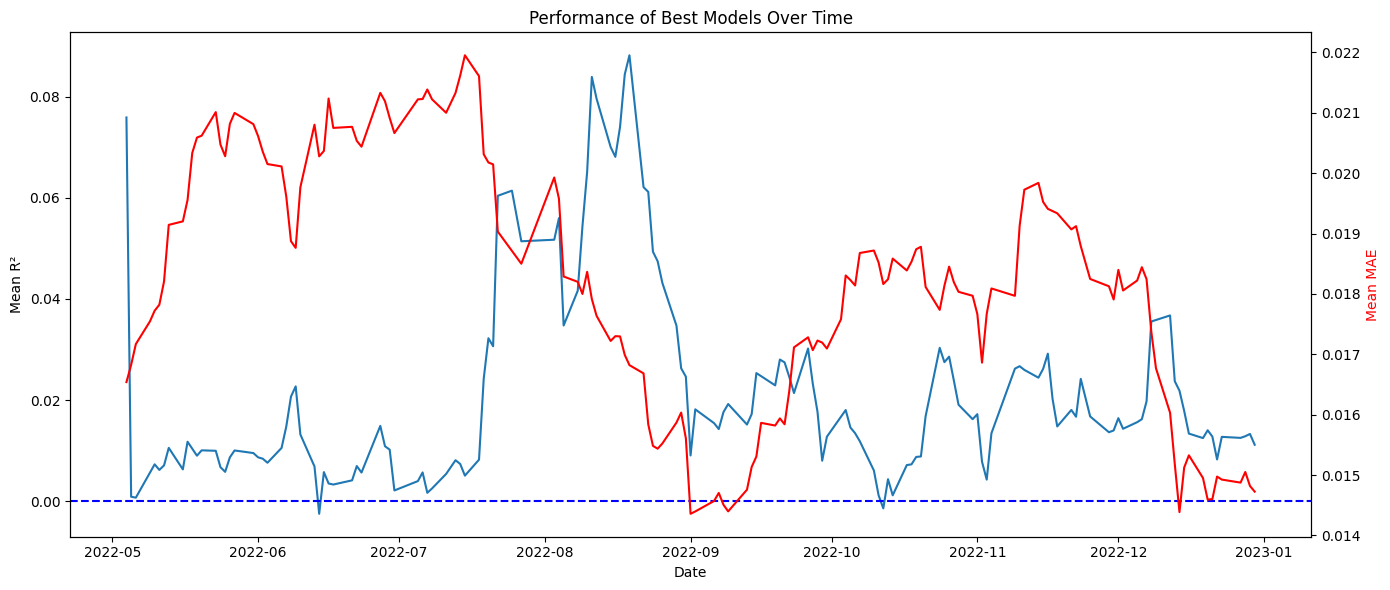

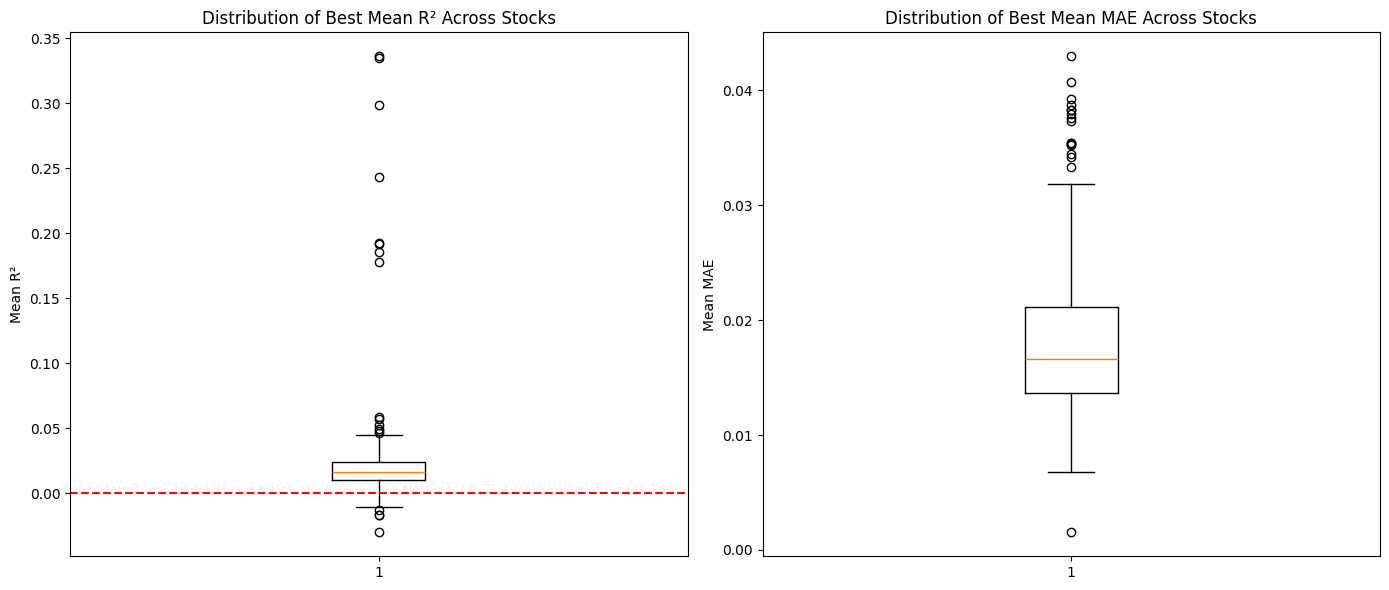

In [19]:


# --- Plot 1: Time series (matplotlib only) ---
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df_time_perf["test_end_date"].to_list(), df_time_perf["mean_r2"].to_list(), label='Mean R²')
ax1.set_xlabel('Date'); ax1.set_ylabel('Mean R²', color='black')
ax1.axhline(0, color='blue', linestyle='--'); ax1.set_title('Performance of Best Models Over Time')
ax2 = ax1.twinx()
ax2.plot(df_time_perf["test_end_date"].to_list(), df_time_perf["mean_mae"].to_list(), label='Mean MAE', color='red')
ax2.set_ylabel('Mean MAE', color='red')
fig.tight_layout(); plt.show(); plt.close(fig)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.boxplot([df_stock_perf_small["mean_r2"].to_numpy()])
ax1.set_title('Distribution of Best Mean R² Across Stocks')
ax1.axhline(0, color='red', linestyle='--'); ax1.set_ylabel("Mean R²")

ax2.boxplot([df_stock_perf_small["mean_mae"].to_numpy()])
ax2.set_title('Distribution of Best Mean MAE Across Stocks'); ax2.set_ylabel("Mean MAE")
plt.tight_layout(); plt.show(); plt.close(fig)



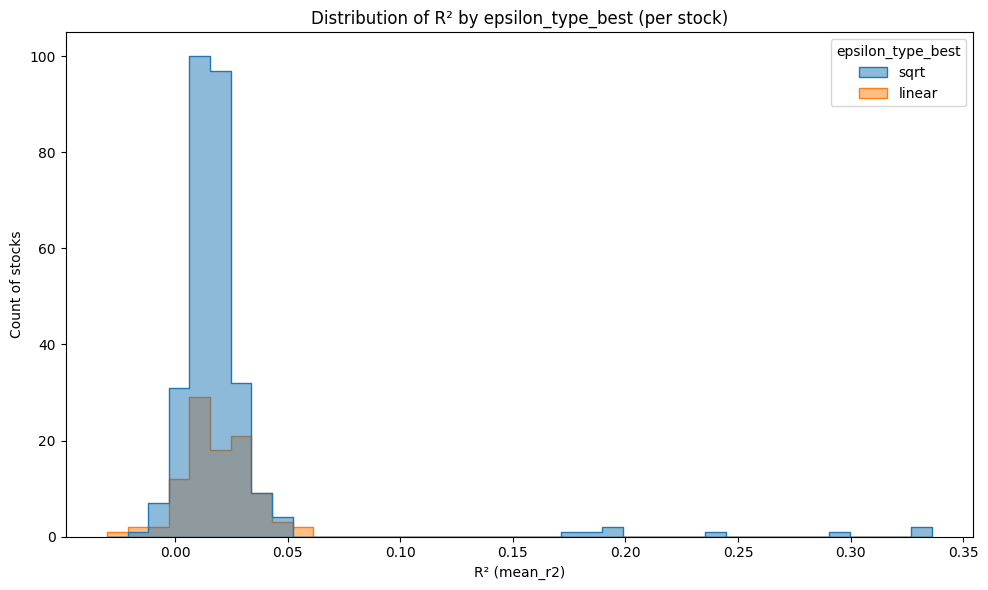

In [62]:
# Histogram of R² (mean_r2) broken out by epsilon_type_best (per stock)
import matplotlib.pyplot as plt
import seaborn as sns

_df_hist = df_best_params.select(["mean_r2", "epsilon_type_best"]).to_pandas()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=_df_hist,
    x="mean_r2",
    hue="epsilon_type_best",
    bins=40,
    element="step",
    stat="count",
    common_norm=False,
    alpha=0.5
)
plt.xlabel("R² (mean_r2)")
plt.ylabel("Count of stocks")
plt.title("Distribution of R² by epsilon_type_best (per stock)")
plt.tight_layout()
plt.show()
